<a href="https://colab.research.google.com/github/Chandrapraksh-prajapat/Regex/blob/main/Machine_learning/ML_10_User_behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np    # analyzed social media user behaviour data
import pandas as pd

# Task 1: Data Understanding & Cleaning
Load dataset, check shape, data types, missing values and duplicates.

In [ ]:
df=pd.read_csv("/content/social_media_user_behavior - social_media_user_behavior.csv")
df.head(2)

,user_id,age,age_group,gender,country,occupation,education_level,income_bracket,relationship_status,primary_platform,...,productivity_impact,platform_satisfaction,account_created_date,account_age_years,is_verified_account,is_content_creator,uses_ai_features,daily_notifications,checks_phone_first_morning,uses_screen_time_limits
0,USR-000001,22,18-24,Non-Binary,Philippines,Teacher/Educator,Doctoral/Professional,$100K-$150K,Married,Facebook,...,No Change,Dissatisfied,2025-05-14,0.9,False,False,False,20,True,False
1,USR-000002,31,25-34,Prefer Not to Say,United Kingdom,Marketing Professional,High School or Below,$50K-$75K,In a Relationship,TikTok,...,No Change,Dissatisfied,2019-07-18,6.7,False,False,False,31,True,False


In [ ]:
#  chcek shape
df.shape

(25000, 45)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   user_id                             25000 non-null  object 
 1   age                                 25000 non-null  int64  
 2   age_group                           25000 non-null  object 
 3   gender                              25000 non-null  object 
 4   country                             25000 non-null  object 
 5   occupation                          25000 non-null  object 
 6   education_level                     25000 non-null  object 
 7   income_bracket                      25000 non-null  object 
 8   relationship_status                 25000 non-null  object 
 9   primary_platform                    25000 non-null  object 
 10  num_platforms_used                  25000 non-null  int64  
 11  daily_screen_time_minutes           25000

In [ ]:
#  check data types
df.dtypes

,0
user_id,object
age,int64
age_group,object
gender,object
country,object
occupation,object
education_level,object
income_bracket,object
relationship_status,object
primary_platform,object


In [ ]:
#  check missing values

df.isnull().sum()

,0
user_id,0
age,0
age_group,0
gender,0
country,0
occupation,0
education_level,0
income_bracket,0
relationship_status,0
primary_platform,0


In [ ]:
#  check duplicate

df.duplicated().sum()

np.int64(0)

In [ ]:
# i performed data cleaning and preprocessing
#   using techniques like encoding and scaling .

# Task 2: Data Preprocessing
Apply Standardization, Normalization and Encoding.

Hint: StandardScaler, MinMaxScaler, pd.get_dummies()

In [ ]:


df = pd.get_dummies(df, columns=['gender','country','primary_platform'], drop_first=True)

df.head(2)

,user_id,age,age_group,occupation,education_level,income_bracket,relationship_status,num_platforms_used,daily_screen_time_minutes,weekly_sessions,...,primary_platform_Pinterest,primary_platform_RedNote,primary_platform_Reddit,primary_platform_Snapchat,primary_platform_Telegram,primary_platform_Threads,primary_platform_TikTok,primary_platform_WhatsApp,primary_platform_X (Twitter),primary_platform_YouTube
0,USR-000001,22,18-24,Teacher/Educator,Doctoral/Professional,$100K-$150K,Married,6,89,6,...,False,False,False,False,False,False,False,False,False,False
1,USR-000002,31,25-34,Marketing Professional,High School or Below,$50K-$75K,In a Relationship,6,161,12,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
# df.info()
num_cols = ['age', 'daily_screen_time_minutes','sleep_hours_per_night','followers_count','engagement_rate_pct']

In [ ]:
## standardization

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

df[num_cols] = sc.fit_transform(df[num_cols])

df.head(2)

,user_id,age,age_group,occupation,education_level,income_bracket,relationship_status,num_platforms_used,daily_screen_time_minutes,weekly_sessions,...,primary_platform_Pinterest,primary_platform_RedNote,primary_platform_Reddit,primary_platform_Snapchat,primary_platform_Telegram,primary_platform_Threads,primary_platform_TikTok,primary_platform_WhatsApp,primary_platform_X (Twitter),primary_platform_YouTube
0,USR-000001,-0.837224,18-24,Teacher/Educator,Doctoral/Professional,$100K-$150K,Married,6,-0.832947,6,...,False,False,False,False,False,False,False,False,False,False
1,USR-000002,-0.243160,25-34,Marketing Professional,High School or Below,$50K-$75K,In a Relationship,6,0.317654,12,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
## normalization

from sklearn.preprocessing import MinMaxScaler

mn = MinMaxScaler()

df[num_cols] = mn.fit_transform(df[num_cols])

df.head()

,user_id,age,age_group,occupation,education_level,income_bracket,relationship_status,num_platforms_used,daily_screen_time_minutes,weekly_sessions,...,primary_platform_Pinterest,primary_platform_RedNote,primary_platform_Reddit,primary_platform_Snapchat,primary_platform_Telegram,primary_platform_Threads,primary_platform_TikTok,primary_platform_WhatsApp,primary_platform_X (Twitter),primary_platform_YouTube
0,USR-000001,0.125000,18-24,Teacher/Educator,Doctoral/Professional,$100K-$150K,Married,6,0.181818,6,...,False,False,False,False,False,False,False,False,False,False
1,USR-000002,0.250000,25-34,Marketing Professional,High School or Below,$50K-$75K,In a Relationship,6,0.337662,12,...,False,False,False,False,False,False,True,False,False,False
2,USR-000003,0.111111,18-24,Legal Professional,High School or Below,$25K-$50K,Single,6,0.729437,22,...,False,False,False,False,False,False,False,False,False,False
3,USR-000004,0.277778,25-34,Unemployed,Some College,$25K-$50K,Single,5,0.329004,14,...,False,False,False,False,False,False,False,False,False,False
4,USR-000005,0.138889,18-24,Sales Professional,Vocational/Trade,$25K-$50K,It's Complicated,8,0.229437,9,...,False,False,True,False,False,False,False,False,False,False


# Task 3: Basic Analysis
Find average age, most common gender, top countries, most used platform.  
Hint: value_counts(), mean()

In [ ]:
#  find average age
df2 = pd.read_csv('/content/social_media_user_behavior - social_media_user_behavior.csv')
df2['age'].mean()

np.float64(34.68384)

In [ ]:
#  find most common gender

df2['gender'].value_counts()


,count
gender,
Female,11930
Male,11574
Non-Binary,1009
Prefer Not to Say,487


In [ ]:
# Top countries

df2['country'].value_counts().head()

,count
country,
India,3598
United States,3175
Brazil,2139
Indonesia,1646
Pakistan,1087


In [ ]:
#  mots used platform

df2['primary_platform'].value_counts().head()

,count
primary_platform,
Instagram,4434
Facebook,3939
YouTube,3759
TikTok,3594
X (Twitter),1544


# Task 4: User Behavior Analysis
Analyze screen time, addiction level and sleep patterns.   
Hint: describe(), groupby()

In [ ]:
#  i analyed  user patterns such as screen time , addiction level and sleep behaviour

In [ ]:
# analyze scree time

df2['daily_screen_time_minutes'].describe()

,daily_screen_time_minutes
count,25000.000000
mean,141.122480
std,62.577221
min,5.000000
25%,95.000000
50%,137.000000
75%,182.000000
max,467.000000


In [ ]:
df2.groupby('gender')['daily_screen_time_minutes'].mean()

,daily_screen_time_minutes
gender,
Female,141.580302
Male,140.583895
Non-Binary,142.729435
Prefer Not to Say,139.377823


In [ ]:
#addiction level

df2['addiction_level_1_to_10'].describe()

,addiction_level_1_to_10
count,25000.000000
mean,2.889920
std,1.698728
min,1.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,10.000000


In [ ]:
df2.groupby('primary_platform')['addiction_level_1_to_10'].mean()

,addiction_level_1_to_10
primary_platform,
Bluesky,2.811715
Discord,3.004348
Facebook,2.867733
Instagram,2.864908
LinkedIn,2.957816
Pinterest,2.951028
RedNote,2.776824
Reddit,2.965551
Snapchat,2.898185


In [ ]:
## Sleep Patterns

df2['sleep_hours_per_night'].describe()

,sleep_hours_per_night
count,25000.000000
mean,7.026960
std,0.940823
min,3.000000
25%,6.400000
50%,7.000000
75%,7.700000
max,11.000000


In [ ]:
df2.groupby('addiction_level_1_to_10')['sleep_hours_per_night'].mean()

,sleep_hours_per_night
addiction_level_1_to_10,
1,7.435288
2,7.165665
3,7.005420
4,6.801590
5,6.612991
6,6.401352
7,6.186462
8,5.944382
9,5.687097


# Task 5: Relationship Analysis
Analyze relationships like screen time vs sleep, followers vs engagement.    
Hint: corr()

In [ ]:
#  also studied relationship  between variables using correlation

In [ ]:
#Analyze relationships like screen time vs sleep,

df2['daily_screen_time_minutes'].corr(df2['sleep_hours_per_night'])

np.float64(-0.5215940624371158)

In [ ]:
# followers vs engagement

df2['followers_count'].corr(df2['engagement_rate_pct'])

np.float64(0.0067958084200271714)

# Task 6: User Segmentation
Create user groups based on usage behavior.   
Hint: df.loc[]

In [ ]:
df2['daily_screen_time_minutes'].describe()

,daily_screen_time_minutes
count,25000.000000
mean,141.122480
std,62.577221
min,5.000000
25%,95.000000
50%,137.000000
75%,182.000000
max,467.000000


In [ ]:
# Create user groups based on usage behavior.

df2.loc[(df2['daily_screen_time_minutes'] > 300)&(df2['addiction_level_1_to_10'] >= 7), 'User_Type'] = 'Highly Addicted'

In [ ]:
df2.loc[(df2['daily_screen_time_minutes'] < 120)&(df2['sleep_hours_per_night'] > 7), 'User_Type'] = 'Healthy User'

In [ ]:
df2.loc[(df2['daily_screen_time_minutes'] >= 120)&(df2['daily_screen_time_minutes'] <= 300), 'User_Type'] = ' Moderate user '

In [ ]:
df2[['daily_screen_time_minutes','addiction_level_1_to_10','sleep_hours_per_night','User_Type']].head()

,daily_screen_time_minutes,addiction_level_1_to_10,sleep_hours_per_night,User_Type
0,89,1,9.1,Healthy User
1,161,2,5.5,Moderate user
2,342,7,4.9,Highly Addicted
3,157,1,7.0,Moderate user
4,111,2,7.4,Healthy User


# Task 7: Business Insights
Answer key business questions using data.         
Hint: groupby(), mean()

In [ ]:
#  created user segmentation like highly addicted , moderate  and healthy users

In [ ]:
# Which type of users are most addicted?
df2.groupby('User_Type')['addiction_level_1_to_10'].mean()

,addiction_level_1_to_10
User_Type,
Moderate user,3.574273
Healthy User,1.721486
Highly Addicted,7.578947


In [ ]:
# which users have lowest sleep hours?
df2.groupby('User_Type')['sleep_hours_per_night'].mean()

,sleep_hours_per_night
User_Type,
Moderate user,6.739848
Healthy User,7.910441
Highly Addicted,5.498026


In [ ]:
# Which users spend the most time on screen?

df2.groupby('User_Type')['daily_screen_time_minutes'].mean()

,daily_screen_time_minutes
User_Type,
Moderate user,177.694429
Healthy User,77.610455
Highly Addicted,332.375000


# Task 8: Recommendations
Provide business suggestions based on insights.          
Hint: Think like a data analyst

In [ ]:
#  finally i extracted business insight and provide recommendations based on the data

In [ ]:
# Introduce screen time alerts for highly addicted users
# Promote healthy usage habits through notifications
# Focus on retaining moderate users
# Target highly engaged users for business promotions

# Task 9: Visualization
Create 1 bar chart, 1 histogram, 1 heatmap only.

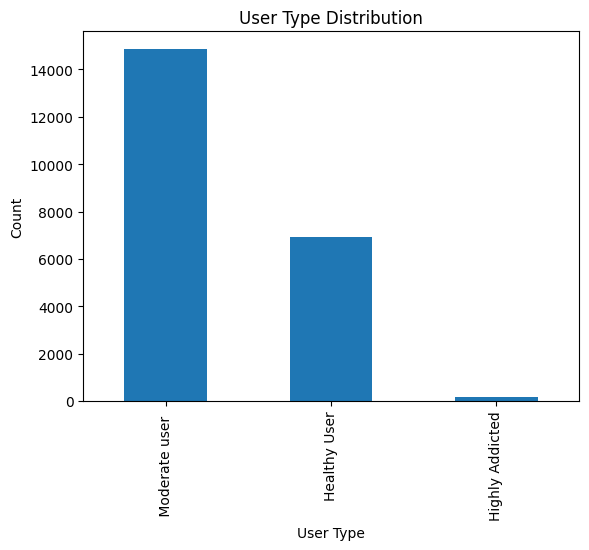

In [ ]:
#  create 1 bar chart

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt

df2['User_Type'].value_counts().plot(kind='bar')

plt.title('User Type Distribution')
plt.xlabel('User Type')
plt.ylabel('Count')
plt.show()

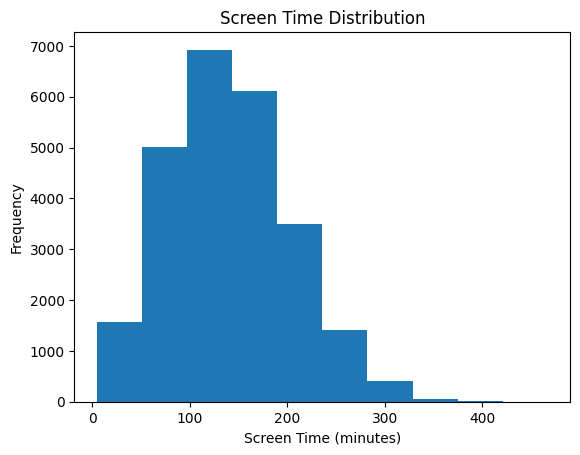

In [ ]:
plt.hist(df2['daily_screen_time_minutes'])

plt.title('Screen Time Distribution')
plt.xlabel('Screen Time (minutes)')
plt.ylabel('Frequency')
plt.show()

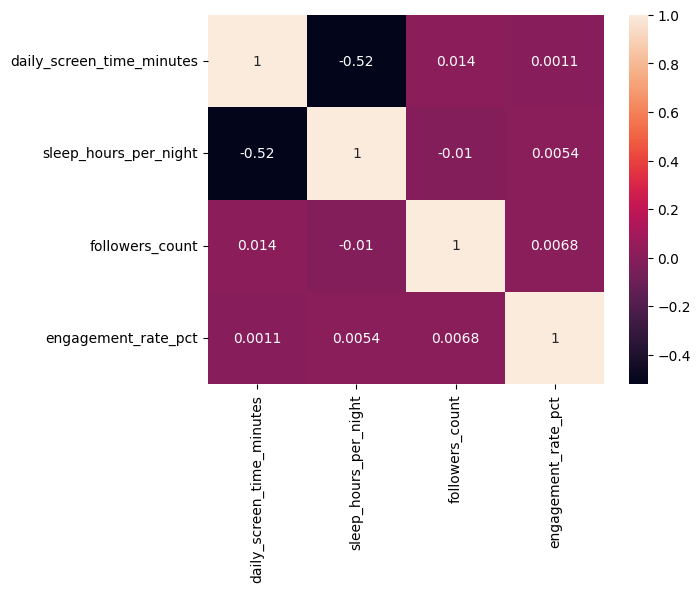

In [ ]:
corr = df2[['daily_screen_time_minutes','sleep_hours_per_night','followers_count','engagement_rate_pct']].corr()

sns.heatmap(corr, annot=True)

plt.show()

In [ ]:
# This project helped me understand how data can be used to make better decisions.